# 04. TỔNG HỢP KẾT QUẢ TỪ 3 NOTEBOOK

**Chạy sau khi đã chạy xong `01`, `02`, `03`**, vì notebook này đọc ba file JSON từ thư mục `ket_qua`.

- Chương 2 + Chương 3: đều dùng Digits, **có thể** so sánh Accuracy/Macro-F1.
- Chương 4: chuỗi nhiệt độ mô phỏng, nên đánh giá bằng MAE/RMSE (°C), **không** so với Accuracy phân loại ảnh.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('ket_qua')
files = [OUT/'chuong2_ml_ket_qua.json', OUT/'chuong3_cnn_ket_qua.json', OUT/'chuong4_rnn_ket_qua.json']
missing = [str(p) for p in files if not p.exists()]
if missing:
    raise FileNotFoundError('Chưa thấy các kết quả: '+', '.join(missing)+'; hãy chạy notebook 01, 02, 03 trước')
ml = json.loads(files[0].read_text(encoding='utf-8'))
cnn = json.loads(files[1].read_text(encoding='utf-8'))
rnn = json.loads(files[2].read_text(encoding='utf-8'))
print('Đã đọc đủ 3 tệp kết quả.')

Đã đọc đủ 3 tệp kết quả.


## So sánh ML và CNN trên Digits

,Mô hình,Accuracy,Macro F1
2,RBF SVM,0.9889,0.9888
0,Logistic regression,0.9852,0.9852
1,Random forest,0.9667,0.9663
3,CNN (PyTorch),0.9667,0.9649


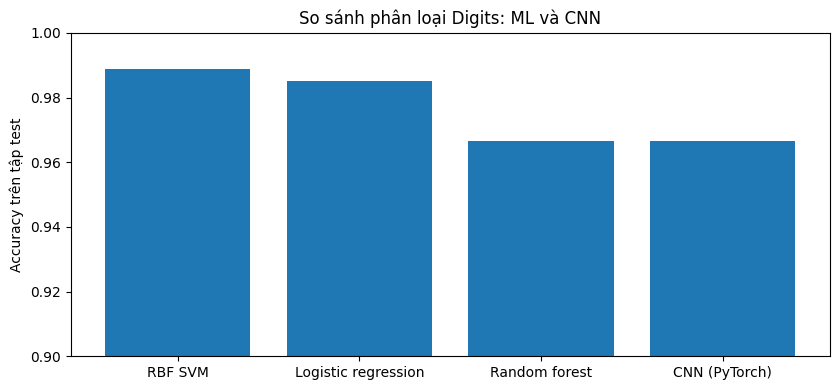

In [2]:
rows = []
for name, metrics in ml['models'].items():
    rows.append({'Mô hình':name, 'Accuracy':metrics['test_accuracy'], 'Macro F1':metrics['test_macro_f1']})
rows.append({'Mô hình':'CNN (PyTorch)', 'Accuracy':cnn['test_accuracy'], 'Macro F1':cnn['test_macro_f1']})
class_table = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
display(class_table.round(4))
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(class_table['Mô hình'], class_table['Accuracy'])
ax.set_ylim(0.9, 1.0); ax.set_ylabel('Accuracy trên tập test')
ax.set_title('So sánh phân loại Digits: ML và CNN')
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'tong_hop_ml_cnn.png', dpi=160)
plt.close(fig)

## So sánh RNN, GRU với baseline trên dữ liệu MÔ PHỎNG

,Mô hình,MAE (°C),RMSE (°C)
1,GRU,0.2601,0.3227
0,SimpleRNN,0.2780,0.3532
2,Persistence baseline,0.5209,0.6126


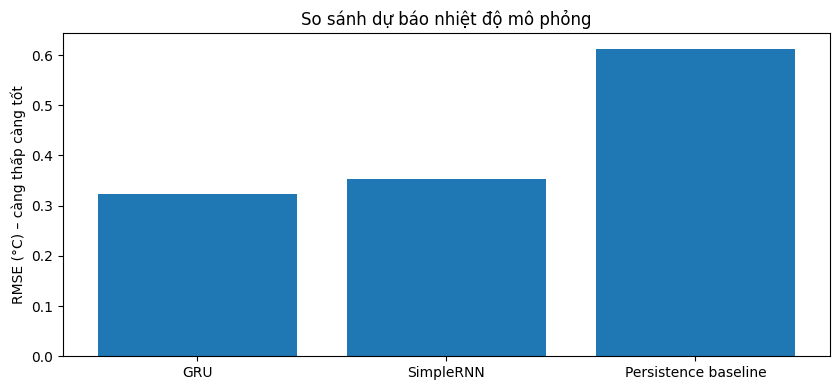

Đã lưu hai bảng tổng hợp và hai biểu đồ.


In [3]:
rnn_rows = [{'Mô hình':name, 'MAE (°C)':m['test_mae_C'], 'RMSE (°C)':m['test_rmse_C']} for name,m in rnn['models'].items()]
rnn_table = pd.DataFrame(rnn_rows).sort_values('RMSE (°C)')
display(rnn_table.round(4))
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(rnn_table['Mô hình'], rnn_table['RMSE (°C)'])
ax.set_ylabel('RMSE (°C) – càng thấp càng tốt')
ax.set_title('So sánh dự báo nhiệt độ mô phỏng')
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'tong_hop_rnn.png', dpi=160)
plt.close(fig)

class_table.to_csv(OUT / 'tong_hop_ml_cnn.csv', index=False, encoding='utf-8-sig')
rnn_table.to_csv(OUT / 'tong_hop_rnn.csv', index=False, encoding='utf-8-sig')
print('Đã lưu hai bảng tổng hợp và hai biểu đồ.')

**Ghi chú:** Kết quả có thể lệch rất nhỏ giữa máy hoặc phiên bản PyTorch/scikit-learn. Khi sửa tham số, hãy cập nhật số liệu và nhận xét trong báo cáo Word cho đúng kết quả bạn chạy thực tế.